# Gen AI Misinformation Detection - Logistic Regression

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [57]:
# Load dataset
df = pd.read_csv('D:\WORKSPACE\MLDLC\machine-learning-playground\GENAI-MISSINFORMATION_LOGISTIC_REG\generative_ai_misinformation_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (500, 31)


,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


In [58]:
# Basic info
print("Data Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['is_misinformation'].value_counts(normalize=True))

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         500 non-null    int64  
 1   post_id                    500 non-null    object 
 2   platform                   500 non-null    object 
 3   timestamp                  500 non-null    object 
 4   date                       500 non-null    object 
 5   time                       500 non-null    object 
 6   month                      500 non-null    object 
 7   weekday                    500 non-null    object 
 8   country                    500 non-null    object 
 9   city                       500 non-null    object 
 10  timezone                   500 non-null    object 
 11  author_id                  500 non-null    object 
 12  author_followers           500 non-null    int64  
 13  author_verified            500 non-null

In [59]:
# Drop unnecessary columns
df = df.drop(columns=['post_id', 'id', 'author_id', 'text'])
print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (500, 27)


In [60]:
# Convert timestamp and extract features
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month

# Drop original timestamp and other unnecessary columns
df = df.drop(columns=['timestamp', 'time', 'date', 'city', 'weekday'])

In [61]:
# Encode categorical variables
categorical_mappings = {
    'model_signature': {'human': 0, 'GPT-like': 1, 'unknown': 2},
    'factcheck_verdict': {'FALSE': 0, 'PARTLY': 1, 'TRUE': 2, 'UNVERIFIED': 3},
    'platform': {'Reddit': 0, 'Telegram': 1, 'Facebook': 2, 'Twitter': 3},
    'country': {'India': 0, 'USA': 1, 'UK': 2, 'Brazil': 3, 'Germany': 4},
    'timezone': {'IST': 0, 'BRT': 1, 'GMT': 2, 'EST': 3, 'CET': 4},
    'day_of_week': {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
}

for col, mapping in categorical_mappings.items():
    df[col] = df[col].map(mapping)

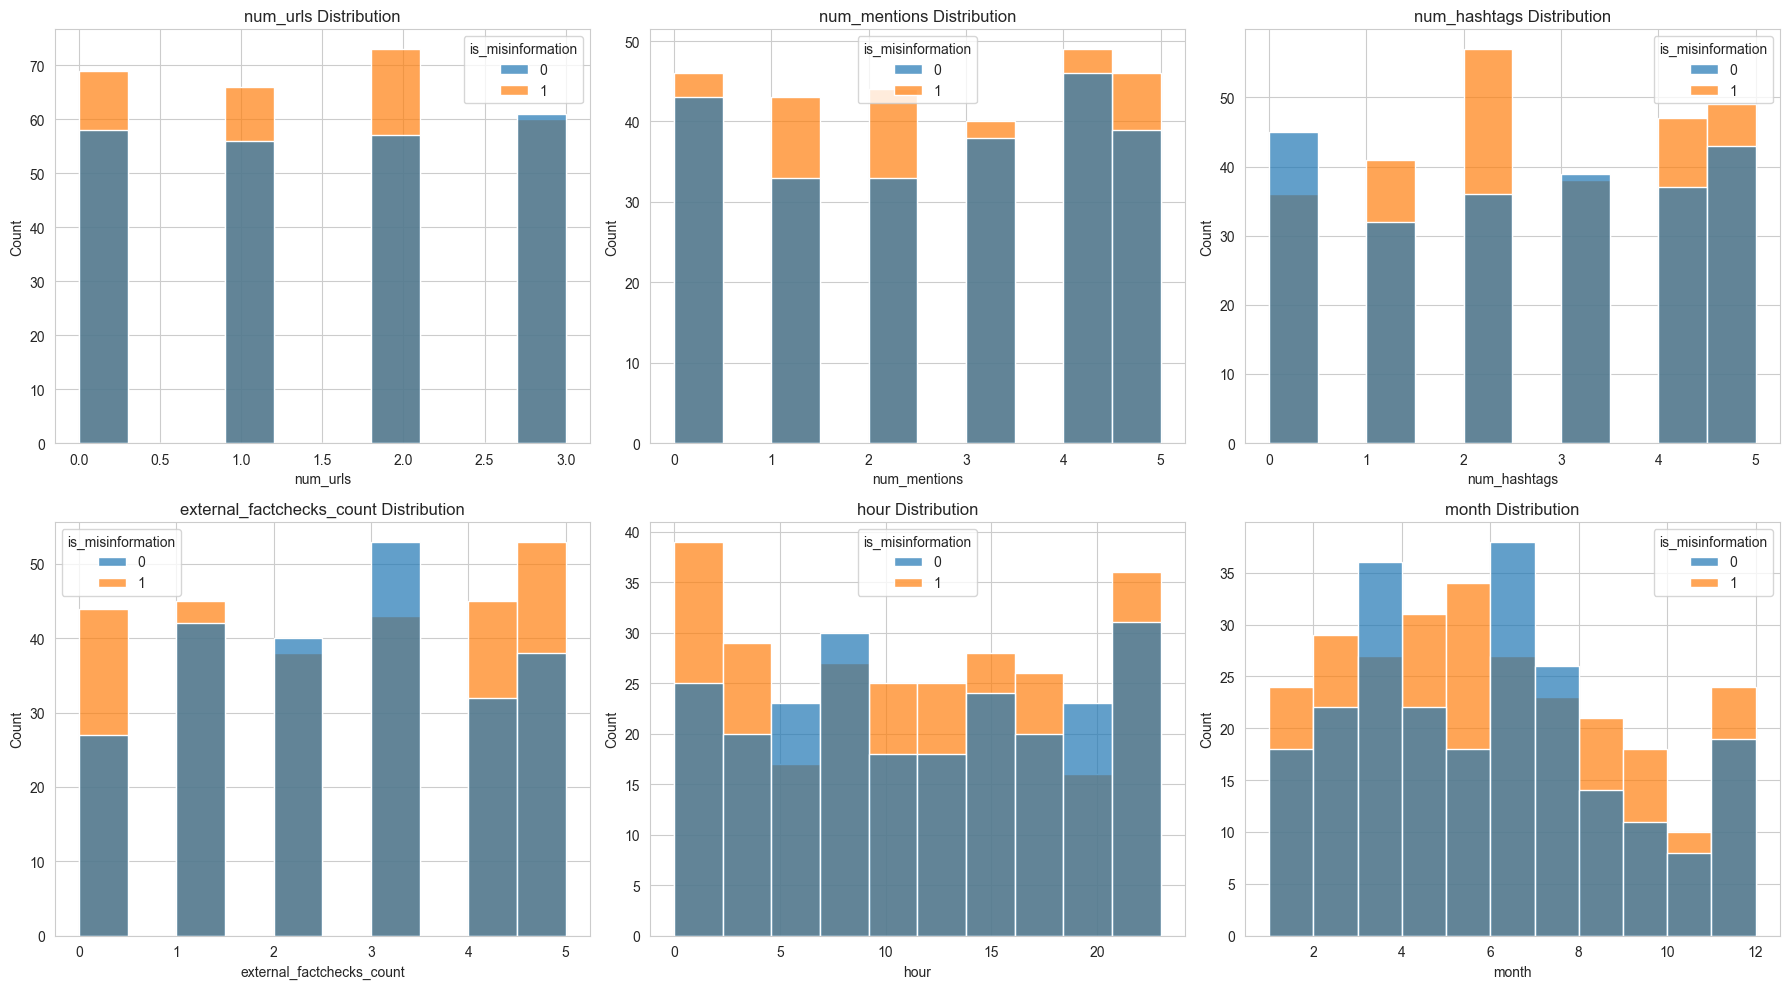

In [84]:
# EDA - Target vs Features
numerical_cols = ['num_urls', 'num_mentions', 'num_hashtags', 'external_factchecks_count', 'hour', 'month']
categorical_cols = ['author_verified', 'platform', 'country', 'timezone', 'model_signature', 'factcheck_verdict']

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='is_misinformation', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

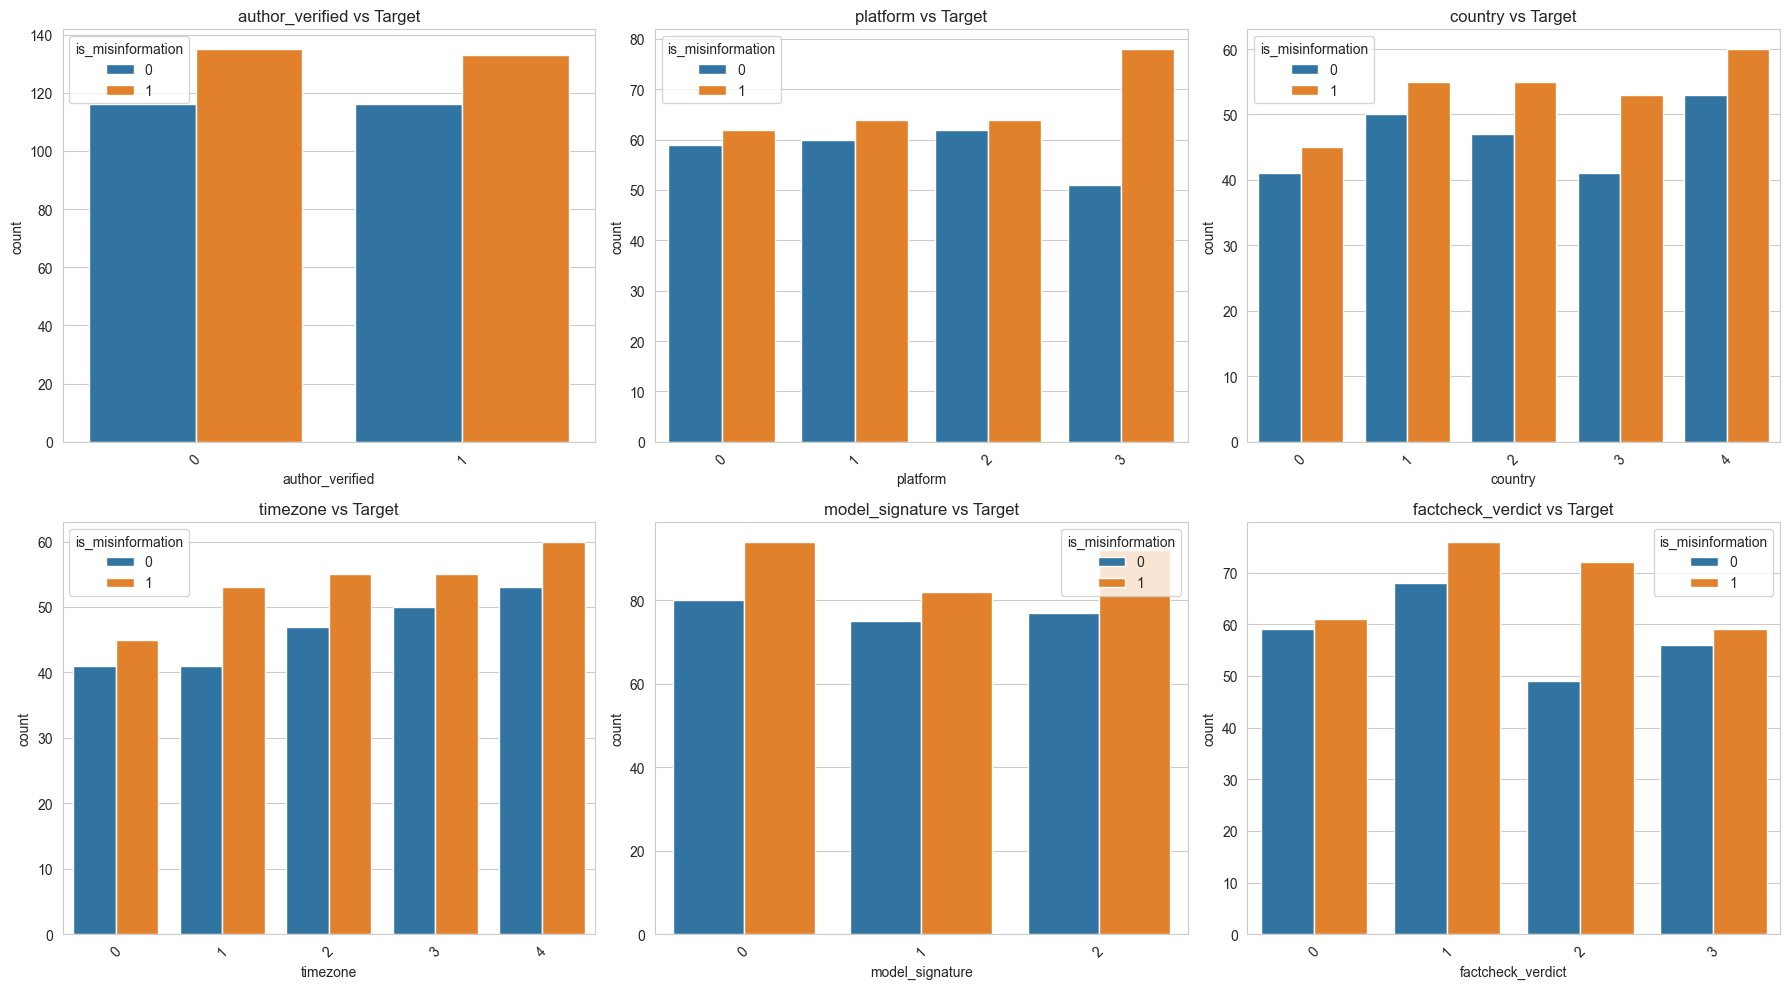

In [78]:
# Categorical analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(data=df, x=col, hue='is_misinformation', ax=axes[i])
        axes[i].set_title(f'{col} vs Target')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

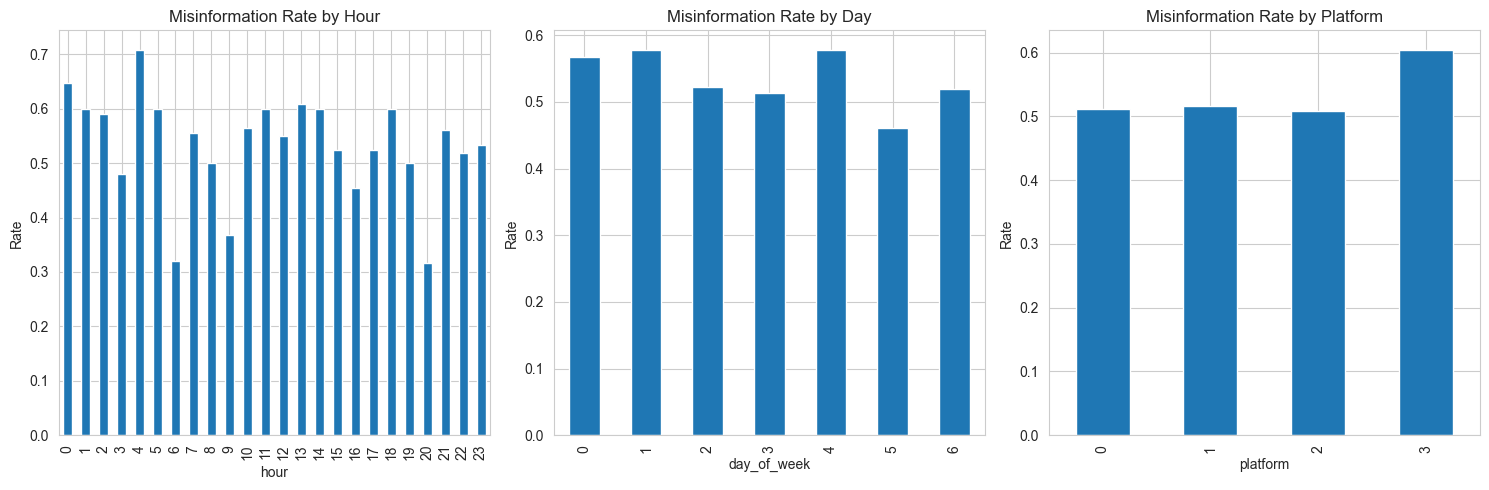

In [79]:
# Time-based analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
hourly_rate = df.groupby('hour')['is_misinformation'].mean()
hourly_rate.plot(kind='bar')
plt.title('Misinformation Rate by Hour')
plt.ylabel('Rate')

plt.subplot(1, 3, 2)
dow_rate = df.groupby('day_of_week')['is_misinformation'].mean()
dow_rate.plot(kind='bar')
plt.title('Misinformation Rate by Day')
plt.ylabel('Rate')

plt.subplot(1, 3, 3)
platform_rate = df.groupby('platform')['is_misinformation'].mean()
platform_rate.plot(kind='bar')
plt.title('Misinformation Rate by Platform')
plt.ylabel('Rate')

plt.tight_layout()
plt.show()

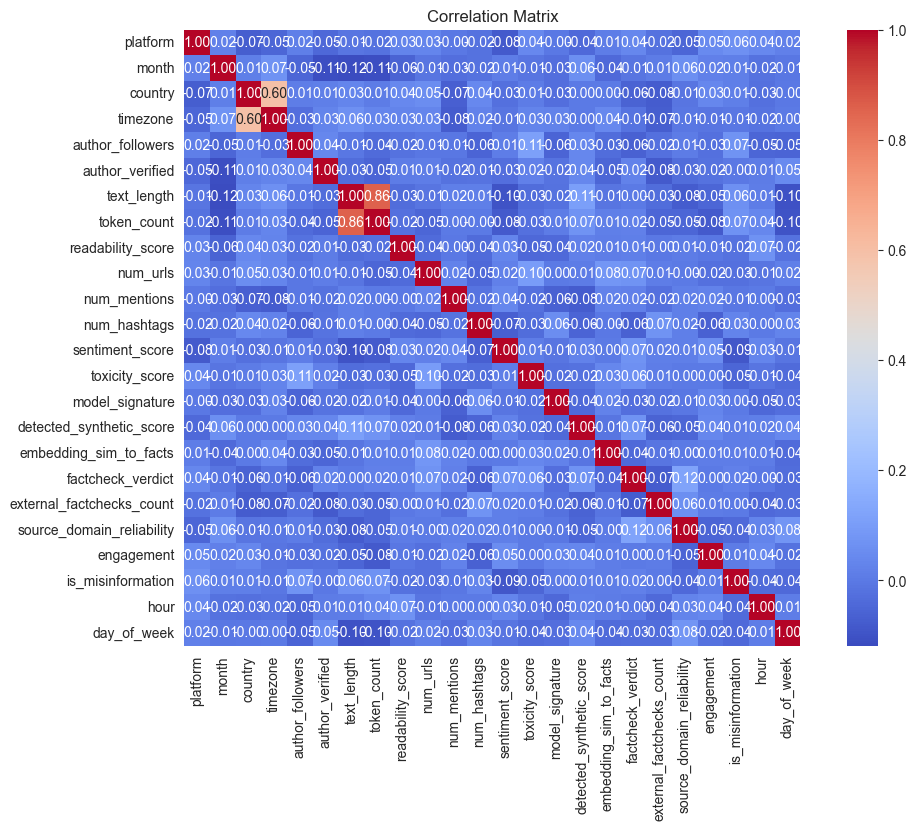

In [80]:
# Correlation analysis
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.show()

In [62]:
# Prepare features and target
X = df.drop(columns=['is_misinformation'])
y = df['is_misinformation']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

Features shape: (500, 23)
Target shape: (500,)
Class distribution: {1: 268, 0: 232}


In [63]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (400, 23), Test shape: (100, 23)


In [64]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


In [69]:
# Train Logistic Regression with Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid (adjusted for better performance)
param_grid = {
    'C': [0.1, 1, 10, 100],  # Removed very small C values that cause underfitting
    'penalty': ['l2'],  # Focus on L2 which is more stable
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Create base model
base_model = LogisticRegression(class_weight='balanced', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Get best model
model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")
print("Model trained successfully with hyperparameter tuning")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation F1 score: 0.4377
Model trained successfully with hyperparameter tuning


In [70]:
# Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [71]:
# Evaluation metrics
print("Model Performance Metrics:")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

Model Performance Metrics:
Accuracy:  0.5200
Precision: 0.5652
Recall:    0.4815
F1-Score:  0.5200
ROC-AUC:   0.5507


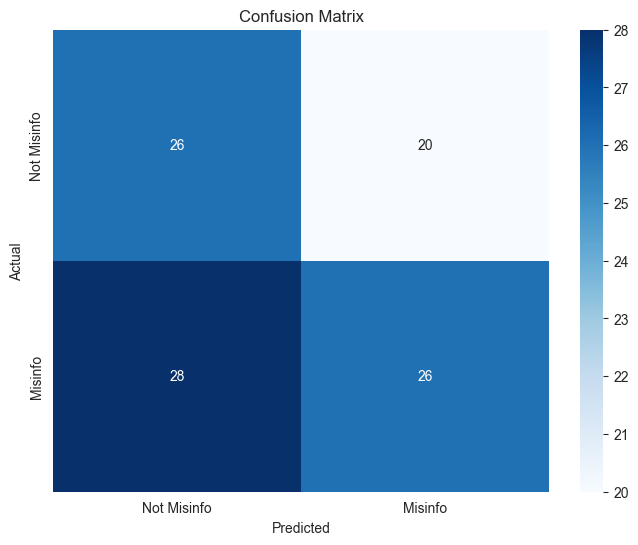

In [72]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Misinfo', 'Misinfo'],
            yticklabels=['Not Misinfo', 'Misinfo'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

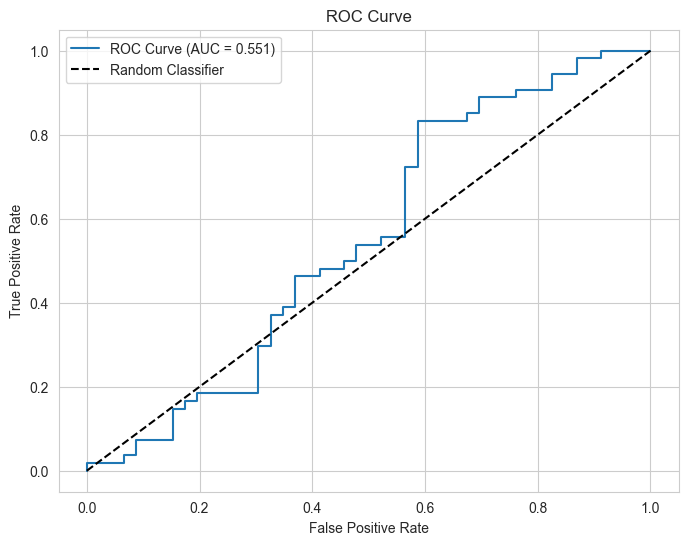

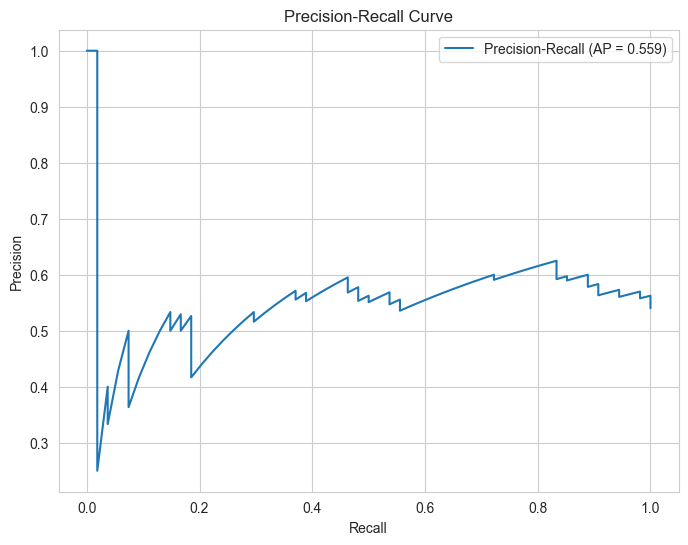


Detailed Classification Report:
                    precision    recall  f1-score   support

Not Misinformation       0.48      0.57      0.52        46
    Misinformation       0.57      0.48      0.52        54

          accuracy                           0.52       100
         macro avg       0.52      0.52      0.52       100
      weighted avg       0.53      0.52      0.52       100



In [73]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# Classification Report
from sklearn.metrics import classification_report
print("\nDetailed Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Not Misinformation', 'Misinformation']))


Cross-Validation ROC-AUC: 0.4579 Â± 0.0562
Cross-Validation F1-Score: 0.4498 Â± 0.0187


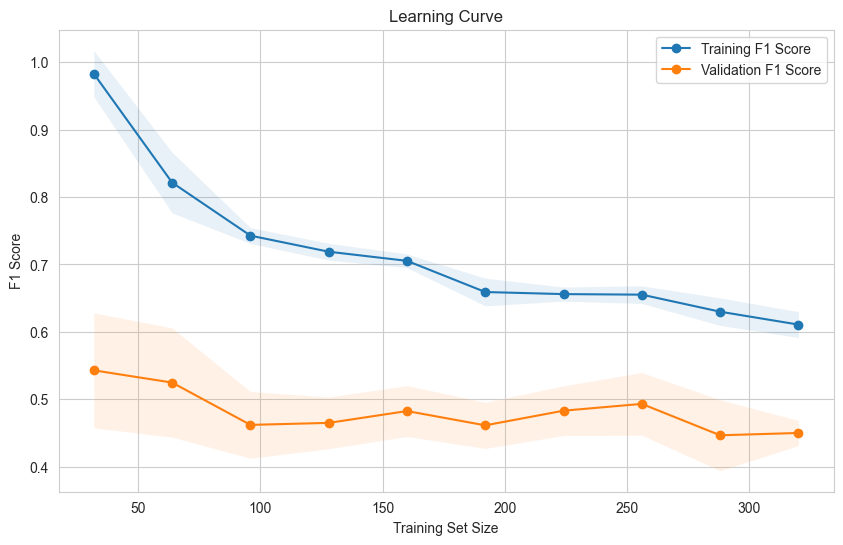

In [74]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"\nCross-Validation ROC-AUC: {cv_scores.mean():.4f} Â± {cv_scores.std():.4f}")

cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
print(f"Cross-Validation F1-Score: {cv_f1.mean():.4f} Â± {cv_f1.std():.4f}")

# Learning Curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train, cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training F1 Score')
plt.plot(train_sizes, val_mean, 'o-', label='Validation F1 Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

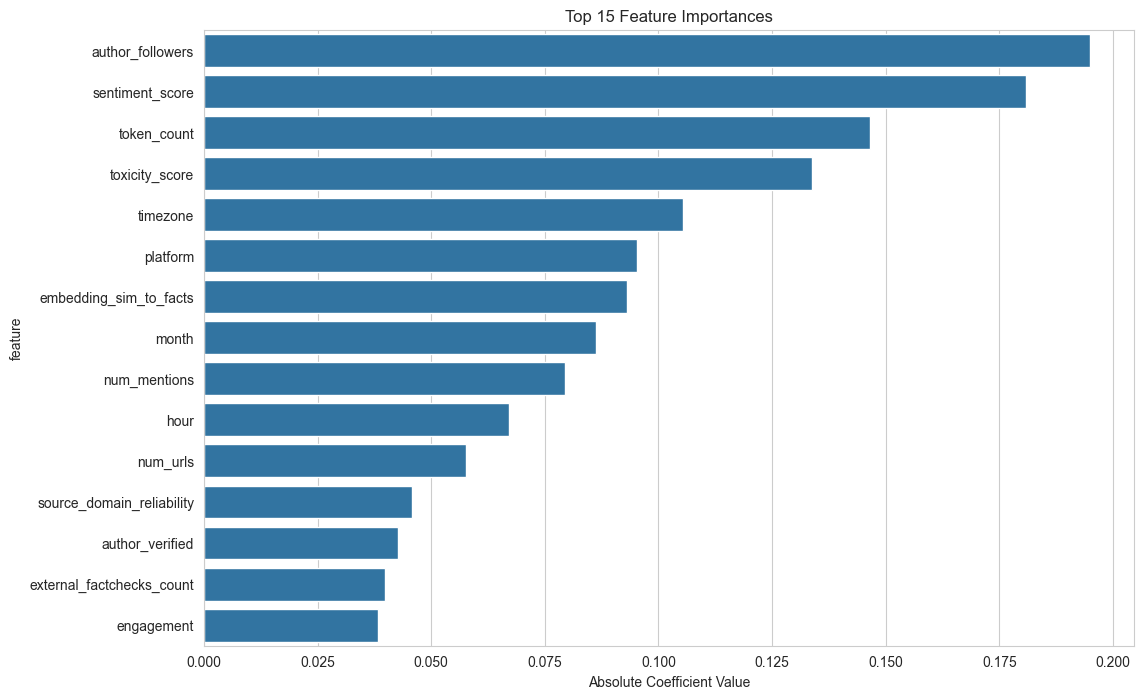

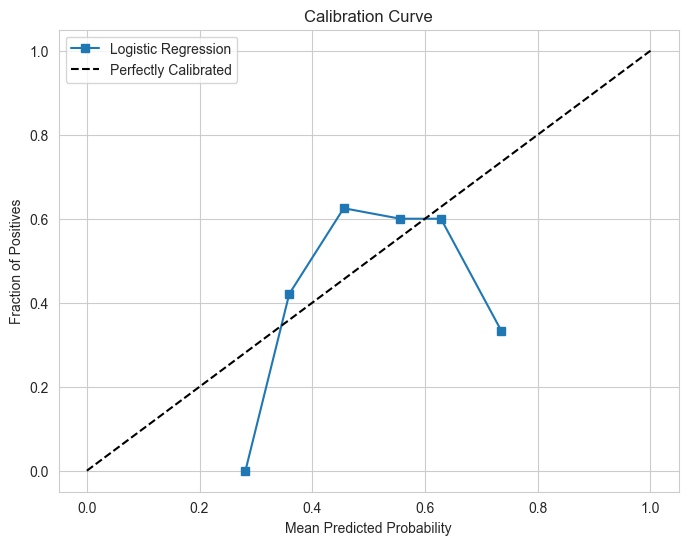

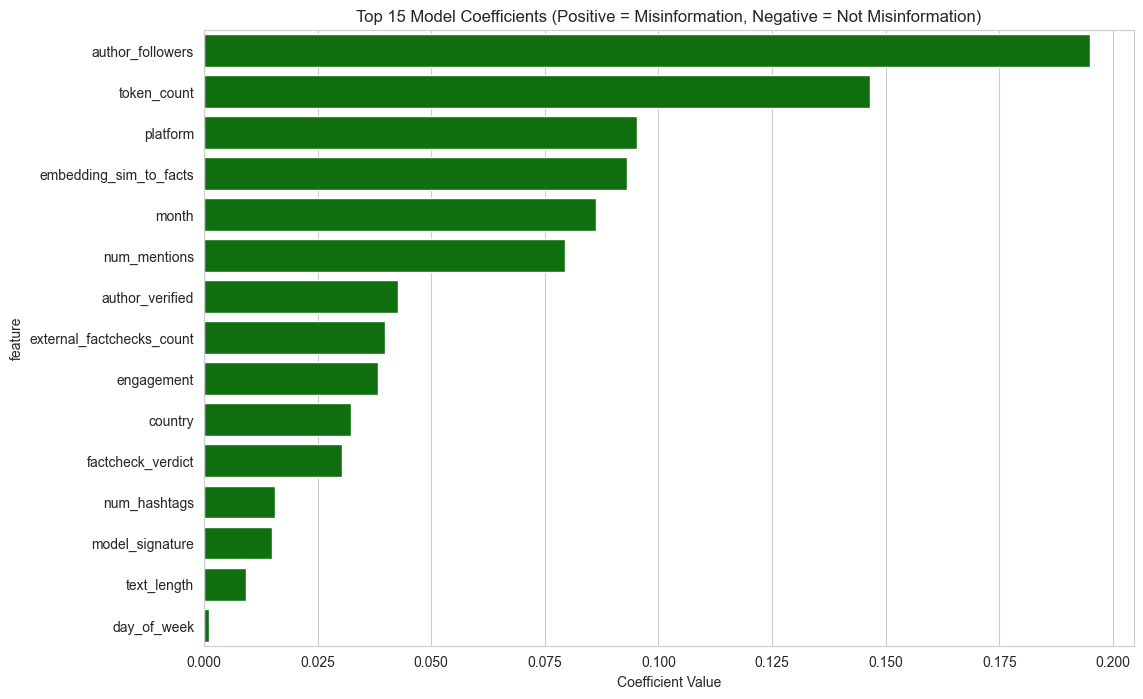

In [75]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances')
plt.xlabel('Absolute Coefficient Value')
plt.show()

# Calibration Curve
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, 's-', label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

# Model Coefficients Analysis
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
coefficients = coefficients.sort_values('coefficient', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in coefficients['coefficient']]
sns.barplot(data=coefficients.head(15), x='coefficient', y='feature', palette=colors)
plt.title('Top 15 Model Coefficients (Positive = Misinformation, Negative = Not Misinformation)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.show()

In [76]:
# Save model and scaler
joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")
print("Files saved:")
print("- logistic_regression_model.pkl")
print("- scaler.pkl")

Model and scaler saved successfully!
Files saved:
- logistic_regression_model.pkl
- scaler.pkl


In [87]:
# Final Model Summary
print("=" * 60)
print("GEN AI MISINFORMATION DETECTION - MODEL SUMMARY")
print("=" * 60)

print(f"\nDataset: {len(df)} samples, {X.shape[1]} features")
print(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]}")
print(f"Classes: {y.value_counts().to_dict()}")

print(f"\nBest Model: Logistic Regression {grid_search.best_params_}")

print("\nPerformance Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

print("\nCross-Validation:")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

print("\nTop Features (Misinformation):")
top_positive = coefficients.nlargest(3, 'coefficient')
for _, row in top_positive.iterrows():
    print(f"{row['feature']}: {row['coefficient']:.4f}")

print("\nTop Features (Legitimate):")
top_negative = coefficients.nsmallest(3, 'coefficient')
for _, row in top_negative.iterrows():
    print(f"{row['feature']}: {row['coefficient']:.4f}")

print("\nModel saved: logistic_regression_model.pkl, scaler.pkl")
print("=" * 60)

GEN AI MISINFORMATION DETECTION - MODEL SUMMARY

Dataset: 500 samples, 23 features
Train/Test split: 400/100
Classes: {1: 268, 0: 232}

Best Model: Logistic Regression {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

Performance Metrics:
Accuracy:  0.5200
Precision: 0.5652
Recall:    0.4815
F1-Score:  0.5200
ROC-AUC:   0.5507

Cross-Validation:
CV ROC-AUC: 0.4579 ± 0.0562
CV F1-Score: 0.4498 ± 0.0187

Top Features (Misinformation):
author_followers: 0.1949
token_count: 0.1465
platform: 0.0952

Top Features (Legitimate):
sentiment_score: -0.1809
toxicity_score: -0.1338
timezone: -0.1054

Model saved: logistic_regression_model.pkl, scaler.pkl
